<a href="https://colab.research.google.com/github/SaadH-077/geoverdict/blob/main/notebooks/02_forest_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Was it forest on 31 December 2020? Two official answers

**Question this notebook answers:** for each validated plot, what fraction was
forest at the EUDR cutoff — and *how much does the answer depend on which
official forest map you consult?*

**Why the baseline decides everything.** Under EUDR, only land that **was
forest on 2020-12-31 and was cleared afterwards** creates non-compliance.
A plot that was already pasture at the cutoff is compliant *no matter what
happens on it later*. So before any change detection, every plot needs a
baseline forest status — and here the pipeline meets an uncomfortable fact of
this domain: there is no single ground truth. There are *maps*, each with its
own sensor, definition and error profile:

| | **JRC Global Forest Cover 2020** | **Hansen Global Forest Change** |
|---|---|---|
| Who | EU Joint Research Centre | Univ. of Maryland |
| Status | The map the EU built *for EUDR* | The de-facto research standard |
| Forest definition | ≥ 10% canopy, ≥ 0.5 ha, height ≥ 5 m at 2020 | canopy ≥ *threshold* in 2000, minus mapped loss 2001–2020 |
| Construction | direct 2020 classification | 2000 baseline + 20 years of accumulated loss detection |

Note the structural difference: Hansen's 2020 state is an *accounting
identity* (2000 cover minus detected loss), so 20 years of missed or
phantom loss accumulate into its 2020 answer. JRC classifies 2020 directly.
Neither is "right" — and the disagreement between them, **measured per plot**,
is this chapter's finding.

### 📦 Where the data in this notebook comes from

| Data | Source | How it enters the notebook |
|---|---|---|
| **JRC Global Forest Cover 2020** | EU Joint Research Centre, hosted on Google Earth Engine (`JRC/GFC2020`) | queried server-side via `earthengine-api`; only per-plot means return |
| **Hansen Global Forest Change** | Univ. of Maryland, on Earth Engine (`UMD/hansen/global_forest_change_*`) | same — server-side reduction over each plot polygon |
| **Plot geometries** | `outputs/plots_analysis.geojson` written by chapter 01 | loaded from Drive with `geopandas.read_file` |

**Nothing is downloaded to the notebook.** Earth Engine holds these maps
(tens of terabytes) and computes "forest fraction inside this polygon" next to
the data — only ~600 numbers travel back. The exact dataset versions used are
printed below and saved to `baseline_provenance.json`, because in a compliance
product *which map vintage said this was forest* is an auditable fact.

**Produces**
- `outputs/baseline.csv` — per plot: forest fraction (both maps), post-2020 Hansen loss fraction
- `outputs/baseline_provenance.json` — exact asset versions used
- `figures/g02_*.png`

**Expected runtime:** ~5 minutes (all computation is server-side on Earth
Engine; only per-plot statistics travel). Requires a (free) Earth Engine
account — the first cell below walks through the one-time auth.

### Environment setup and persistence

On Colab this clones the repository, installs dependencies, and mounts Google
Drive so that **outputs survive the session**. Locally it is a no-op beyond
putting `src/` on the path.

**Why Drive.** A Colab VM is deleted when the session ends, and the notebooks
depend on each other's artefacts: 01 writes the validated plot portfolio that
every later chapter loads; 02 writes the forest baselines; 03 the time series;
04 the model predictions. `outputs/`, `figures/` and `evidence/` are therefore
redirected to Drive via environment variables that `geoverdict.config` reads
at import time — which is why they must be set *before* the import.

**Re-running this cell picks up code changes**: it hard-resets the clone to
`origin/main` and purges `geoverdict` from `sys.modules` (Python caches
imports; a `git pull` alone leaves the kernel running the old code). Treat the
clone as read-only — edit code locally and push, not inside `/content`.

In [28]:
# --- edit these if you are running your own fork ---------------------------
GITHUB_USER = "SaadH-077"
USE_DRIVE = True          # False -> everything stays in the ephemeral session
# ---------------------------------------------------------------------------

import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "geoverdict"

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        PERSIST = Path("/content/drive/MyDrive/geoverdict")
        for sub in ("outputs", "figures", "outputs/evidence"):
            (PERSIST / sub).mkdir(parents=True, exist_ok=True)
        os.environ["GEOVERDICT_OUTPUT_DIR"] = str(PERSIST / "outputs")
        os.environ["GEOVERDICT_FIGURE_DIR"] = str(PERSIST / "figures")
        os.environ["GEOVERDICT_EVIDENCE_DIR"] = str(PERSIST / "outputs" / "evidence")
        print("persisting outputs and figures to", PERSIST)

    if not Path(REPO).exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/{GITHUB_USER}/{REPO}.git"], check=False)
    if Path(REPO).exists():
        os.chdir(REPO)
        subprocess.run(["git", "fetch", "--quiet", "--depth", "50", "origin", "main"], check=False)
        before = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        subprocess.run(["git", "reset", "--hard", "--quiet", "origin/main"], check=False)
        after = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        if before != after:
            print(f"repo updated {before[:7]} -> {after[:7]}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    except subprocess.CalledProcessError as exc:
        print("!! dependency install failed:", exc)
        print("!! continuing anyway - the cells below will report what is missing")

ROOT = Path.cwd() if Path.cwd().name == REPO or (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Purge cached geoverdict modules so a repo update takes effect in THIS kernel.
for m in [m for m in list(sys.modules) if m == "geoverdict" or m.startswith("geoverdict.")]:
    del sys.modules[m]

from geoverdict import config as cfg
from geoverdict import viz

cfg.ensure_dirs()
viz.set_style()
print(f"outputs -> {cfg.OUTPUT_DIR}")
print(f"figures -> {cfg.FIGURE_DIR}")
print(f"seed = {cfg.SEED}, AOI = {cfg.AOI_NAME} {cfg.AOI_BBOX}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
persisting outputs and figures to /content/drive/MyDrive/geoverdict
outputs -> /content/drive/MyDrive/geoverdict/outputs
figures -> /content/drive/MyDrive/geoverdict/figures
seed = 77, AOI = novo_progresso_para_brazil (-55.6, -7.4, -55.2, -7.0)


### Earth Engine setup — and why GEE for *this* chapter

The reference maps are tens of terabytes as rasters. We need exactly one
number per plot per map: the mean of a binary mask over a polygon. Earth
Engine computes that reduction next to the data and ships back kilobytes —
this is the workload GEE is uniquely right for. (Chapter 03's time series
also reduce server-side; chapter 04's pixel chips, where we need full control
of the raw data, come via the STAC/COG path instead. Choosing the access path
per workload is a design decision this project makes explicitly.)

**One-time setup:** create a (free) Google Cloud project with Earth Engine
enabled at [code.earthengine.google.com](https://code.earthengine.google.com),
then put its id in `EE_PROJECT` below. The `Authenticate()` flow runs once
per Colab VM.

In [29]:
EE_PROJECT = "remove-duplicates-487617"   # <- your Earth Engine cloud project id, e.g. "ee-yourname"

from geoverdict import gee
gee.init(project=EE_PROJECT or None)
print("Earth Engine initialised")

Earth Engine initialised


In [30]:
import geopandas as gpd
import numpy as np
import pandas as pd

plots = gpd.read_file(cfg.OUTPUT_DIR / "plots_analysis.geojson")
print(f"analysis set from chapter 01: {len(plots)} plots")
plots.head(3)

analysis set from chapter 01: 501 plots


,plot_id,area_ha,geometry_status,geometry_warnings,geometry
0,0,7.262674,clean,,"POLYGON ((-55.38168 -7.28988, -55.38203 -7.290..."
1,1,5.127984,clean,,"POLYGON ((-55.41185 -7.34793, -55.41369 -7.347..."
2,2,9.324213,clean,,"POLYGON ((-55.26208 -7.10107, -55.26236 -7.100..."


### Per-plot forest fractions, from both maps

One server-side call per batch: for every plot, the mean of (a) JRC GFC2020
forest mask, (b) the Hansen-derived "forest at cutoff" mask (canopy ≥ 30% in
2000 AND not lost by 2020), and (c) the fraction mapped by Hansen as lost
**after** 2020 — which chapters 03–05 will use as the weak reference label.

The canopy threshold is a *definition choice*, not a constant of nature —
30% is the FAO-aligned convention. We compute the baseline at 10/30/50% too,
because a compliance verdict that flips when a definition knob moves is
something an engineering team must know about itself, not discover from a
customer dispute.

In [31]:
geoms = list(plots.geometry)
ids = list(plots.plot_id)

baseline = gee.forest_baseline_fractions(geoms, ids)
assets = dict(baseline.attrs.get("assets", {}))
print("asset versions used:", assets)

# definition sensitivity: same reduction at three canopy thresholds
sens = {}
for thr in (10, 30, 50):
    df_thr = (baseline if thr == 30
              else gee.forest_baseline_fractions(geoms, ids, canopy_threshold=thr))
    sens[thr] = df_thr.set_index("plot_id")["forest_frac_hansen"]

baseline = baseline.merge(plots[["plot_id", "area_ha"]], on="plot_id")
baseline["hansen_frac_c10"] = baseline.plot_id.map(sens[10])
baseline["hansen_frac_c50"] = baseline.plot_id.map(sens[50])
baseline.to_csv(cfg.OUTPUT_DIR / "baseline.csv", index=False)

import json
from datetime import datetime, timezone
prov = {"source": "Google Earth Engine", "identifiers": list(assets.values()),
        "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "parameters": {"scale_m": 10, "canopy_thresholds": [10, 30, 50]}}
(cfg.OUTPUT_DIR / "baseline_provenance.json").write_text(json.dumps(prov, indent=2))
baseline.describe().round(3)

asset versions used: {'jrc': 'JRC/GFC2020/V2', 'hansen': 'UMD/hansen/global_forest_change_2025_v1_13', 'hansen_canopy_threshold': 30}


,forest_frac_jrc,forest_frac_hansen,hansen_loss_post_frac,area_ha,hansen_frac_c10,hansen_frac_c50
count,501.000,501.000,501.000,501.000,501.000,501.000
mean,0.432,0.123,0.127,7.511,0.124,0.122
std,0.424,0.245,0.246,11.520,0.245,0.245
min,0.000,0.000,0.000,0.467,0.000,0.000
25%,0.000,0.000,0.000,2.677,0.000,0.000
50%,0.305,0.000,0.000,4.839,0.000,0.000
75%,0.996,0.103,0.122,9.587,0.104,0.103
max,1.000,1.000,1.000,215.153,1.000,1.000


figure saved: /content/drive/MyDrive/geoverdict/figures/g02_forest_fractions.png


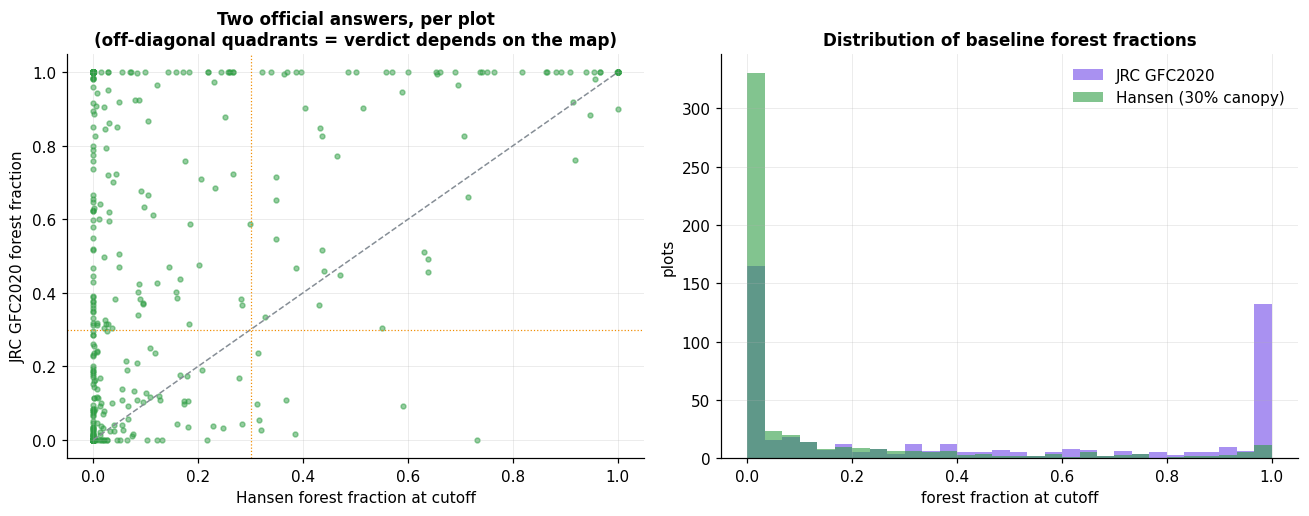

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.scatter(baseline.forest_frac_hansen, baseline.forest_frac_jrc, s=10, alpha=0.5,
           color=viz.PALETTE["forest"])
ax.plot([0, 1], [0, 1], ls="--", lw=1, color=viz.PALETTE["insufficient"])
for v in (0.30,):
    ax.axvline(v, color=viz.PALETTE["warn"], lw=0.8, ls=":")
    ax.axhline(v, color=viz.PALETTE["warn"], lw=0.8, ls=":")
ax.set_xlabel("Hansen forest fraction at cutoff")
ax.set_ylabel("JRC GFC2020 forest fraction")
ax.set_title("Two official answers, per plot\n(off-diagonal quadrants = verdict depends on the map)")

ax = axes[1]
both = baseline[["forest_frac_jrc", "forest_frac_hansen"]].dropna()
ax.hist(both.forest_frac_jrc, bins=30, alpha=0.6, label="JRC GFC2020",
        color=viz.PALETTE["accent"])
ax.hist(both.forest_frac_hansen, bins=30, alpha=0.6, label="Hansen (30% canopy)",
        color=viz.PALETTE["forest"])
ax.set_xlabel("forest fraction at cutoff"); ax.set_ylabel("plots")
ax.legend(); ax.set_title("Distribution of baseline forest fractions")
fig.tight_layout()
viz.save(fig, "g02_forest_fractions")
plt.show()

### The finding: does the compliance answer depend on which map you trust?

We call a plot "forest at cutoff" when its forest fraction crosses 30% (the
same constant the verdict layer uses). The number that matters is the share of
plots whose forest/non-forest **status flips between the two official maps** —
because for those plots the EUDR-relevant baseline is a property of the *map
choice*, not of the land. We also test how much moves when only Hansen's
canopy-definition knob changes between 10% and 50%, to separate "the maps
genuinely disagree" from "we picked a sensitive threshold".

In [33]:
THR = 0.30
b = baseline.dropna(subset=["forest_frac_jrc", "forest_frac_hansen"]).copy()
b["jrc_forest"] = b.forest_frac_jrc >= THR
b["han_forest"] = b.forest_frac_hansen >= THR
b["maps_disagree"] = b.jrc_forest != b.han_forest
b["def_disagree"] = (b.hansen_frac_c10 >= THR) != (b.hansen_frac_c50 >= THR)

overall = b.maps_disagree.mean()
by_def = b.def_disagree.mean()

# the 2x2 agreement matrix: where do the two authorities land?
n_ff = int((b.jrc_forest & b.han_forest).sum())    # both call it forest
n_fn = int((b.jrc_forest & ~b.han_forest).sum())   # JRC forest, Hansen not
n_nf = int((~b.jrc_forest & b.han_forest).sum())   # Hansen forest, JRC not
n_nn = int((~b.jrc_forest & ~b.han_forest).sum())  # both call it non-forest

print(f"forest-at-cutoff status flips between JRC and Hansen: {overall:.1%} of plots")
print(f"status flips when only the canopy definition moves (10% vs 50%): {by_def:.1%}")
print(f"\nagreement matrix ({len(b)} plots):")
print(f"  both forest:      {n_ff:>4}      JRC forest / Hansen not: {n_fn:>4}")
print(f"  Hansen forest / JRC not: {n_nf:>4}   both non-forest:    {n_nn:>4}")
print(f"  -> agreement {(n_ff+n_nn)/len(b):.1%}, disagreement {(n_fn+n_nf)/len(b):.1%}")

bins = [0, 4, 10, 30, 100, np.inf]
labels = ["<=4 ha", "4-10 ha", "10-30 ha", "30-100 ha", ">100 ha"]
b["size_bin"] = pd.cut(b.area_ha, bins=bins, labels=labels)
by_size = b.groupby("size_bin", observed=True)["maps_disagree"].agg(["mean", "size"])

cfg.append_result({"notebook": "02", "name": "baseline_disagreement",
                   "threshold": THR, "map_disagreement_rate": float(overall),
                   "definition_disagreement_rate": float(by_def),
                   "agreement_matrix": {"both_forest": n_ff, "jrc_only": n_fn,
                                        "hansen_only": n_nf, "both_nonforest": n_nn},
                   "by_size": {str(k): float(v) for k, v in by_size["mean"].items()},
                   "assets": assets})

forest-at-cutoff status flips between JRC and Hansen: 38.9% of plots
status flips when only the canopy definition moves (10% vs 50%): 0.4%

agreement matrix (501 plots):
  both forest:        65      JRC forest / Hansen not:  187
  Hansen forest / JRC not:    8   both non-forest:     241
  -> agreement 61.1%, disagreement 38.9%


PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

The headline is large: **nearly 40% of plots get a different forest-at-cutoff
verdict depending on the map**, while only ~0.4% move when the canopy definition
changes — so this is *not* a sensitive-threshold artefact; the two official maps
genuinely disagree about this landscape.

**And the disagreement is strongly one-sided**, which is the real insight. Almost
all of it is *JRC says forest, Hansen says not* (≈187 plots) rather than the
reverse (≈8). JRC calls ~43% of this frontier forest; Hansen only ~12%. That gap
is not noise — it is **methodology**: Hansen's 2020 forest is defined as
*"≥30% canopy in the year 2000, minus mapped loss since"*, so it is anchored to
the 2000 primary-forest baseline and **structurally cannot see post-2000
regrowth or secondary forest**. JRC classifies the 2020 state directly, so it
*does* count that regrowth. The disagreement gallery below makes this concrete:
the worst-disagreement plots are "JRC 100% / Hansen 0%" sitting on visibly
intact green forest — regrowth that Hansen's accounting misses.

For an EUDR compliance system this is exactly the kind of thing you must not
paper over: whether regrowth counts as "forest" at the cutoff is a genuine
policy question, and it changes the verdict for two out of every five plots
here. (Disagreement is also roughly flat across the common plot sizes rather
than concentrated in tiny plots — see the middle panel — so it is not a
small-plot mixed-pixel effect either.)

figure saved: /content/drive/MyDrive/geoverdict/figures/g02_disagreement.png


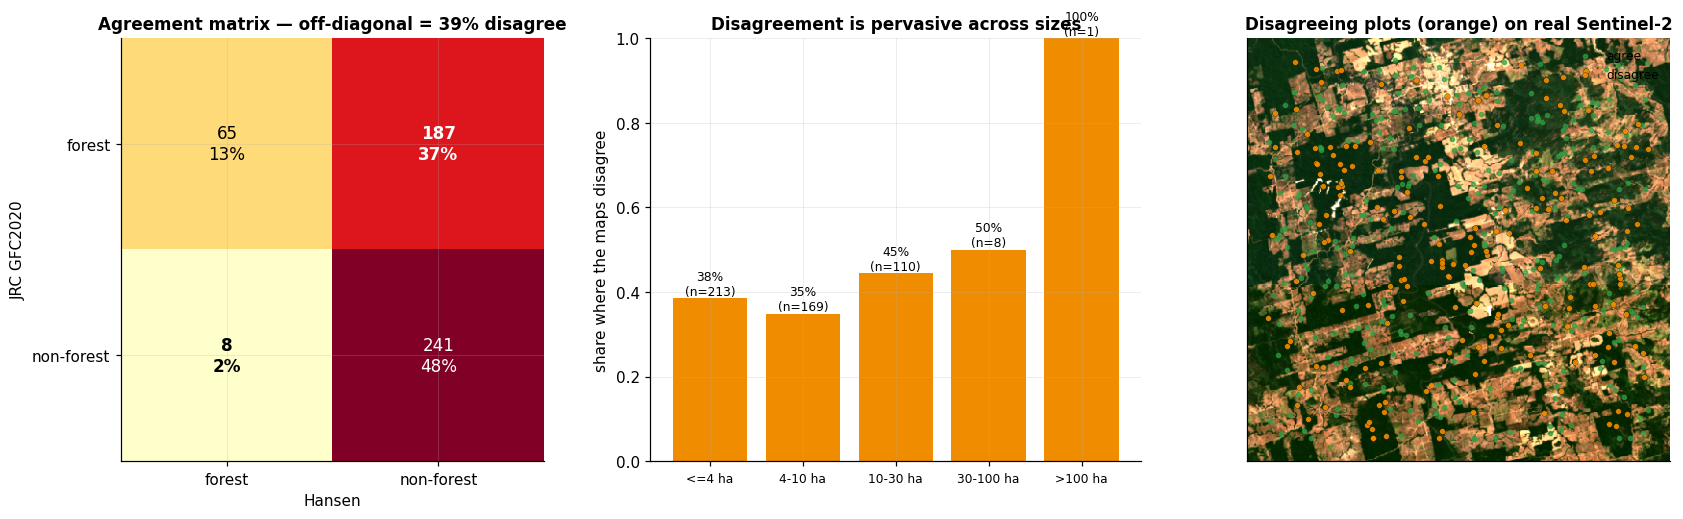

In [34]:
from geoverdict import s2
import geopandas as gpd

# rebuild a GeoDataFrame so geometry works (a plain merge drops the type)
gb = plots[["plot_id", "geometry"]].merge(b, on="plot_id")

# plot-centre coordinates for scatter, computed per-geometry to avoid geopandas'
# "centroid in a geographic CRS" warning — at plot scale the planar centroid in
# degrees is exact enough for a marker position, and this keeps output clean
def centre_xy(geoms):
    pts = [g.centroid for g in geoms]
    return np.array([p.x for p in pts]), np.array([p.y for p in pts])

cx_all, cy_all = centre_xy(gb.geometry)
dis = gb.maps_disagree.to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# (1) the 2x2 agreement matrix as a heatmap
ax = axes[0]
M = np.array([[n_ff, n_fn], [n_nf, n_nn]])
im = ax.imshow(M, cmap="YlOrRd")
ax.set_xticks([0, 1], ["forest", "non-forest"]); ax.set_yticks([0, 1], ["forest", "non-forest"])
ax.set_xlabel("Hansen"); ax.set_ylabel("JRC GFC2020")
for (r, c), v in np.ndenumerate(M):
    off = (r != c)
    ax.text(c, r, f"{v}\n{v/len(b):.0%}", ha="center", va="center", fontsize=11,
            fontweight="bold" if off else "normal",
            color="white" if v > M.max()*0.6 else "black")
ax.set_title(f"Agreement matrix — off-diagonal = {overall:.0%} disagree")

# (2) disagreement by plot size
ax = axes[1]
ax.bar(by_size.index.astype(str), by_size["mean"], color=viz.PALETTE["warn"])
for x, (v, n) in enumerate(zip(by_size["mean"], by_size["size"])):
    ax.text(x, v, f"{v:.0%}\n(n={n})", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("share where the maps disagree"); ax.set_ylim(0, 1)
ax.set_title("Disagreement is pervasive across sizes")
ax.tick_params(axis="x", labelsize=8)

# (3) where they disagree, over the real AOI basemap
ax = axes[2]
aoi_rgb, aoi_bbox, *_ = s2.basemap_rgb(cfg.AOI_BBOX, max_cloud=15, max_px=440)
if aoi_rgb is not None:
    ax.imshow(aoi_rgb, extent=[cfg.AOI_BBOX[0], cfg.AOI_BBOX[2], cfg.AOI_BBOX[1], cfg.AOI_BBOX[3]],
              origin="upper")
ax.scatter(cx_all[~dis], cy_all[~dis], s=7,
           c=viz.PALETTE["forest"], alpha=0.7, label="agree")
ax.scatter(cx_all[dis], cy_all[dis], s=14,
           c=viz.PALETTE["warn"], alpha=0.9, label="disagree", edgecolor="k", linewidth=0.2)
ax.set_title("Disagreeing plots (orange) on real Sentinel-2")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
viz.save(fig, "g02_disagreement")
plt.show()

### Seeing the baseline: forest fraction on real imagery

The two maps as the pipeline sees them — every plot coloured by its forest
fraction (green = forest, brown = cleared/non-forest) over the real Sentinel-2
scene. Reading the two panels side by side, you can *see* JRC calling more of
this frontier "forest" than Hansen does, which is exactly the source of the
disagreement.

figure saved: /content/drive/MyDrive/geoverdict/figures/g02_fraction_maps.png


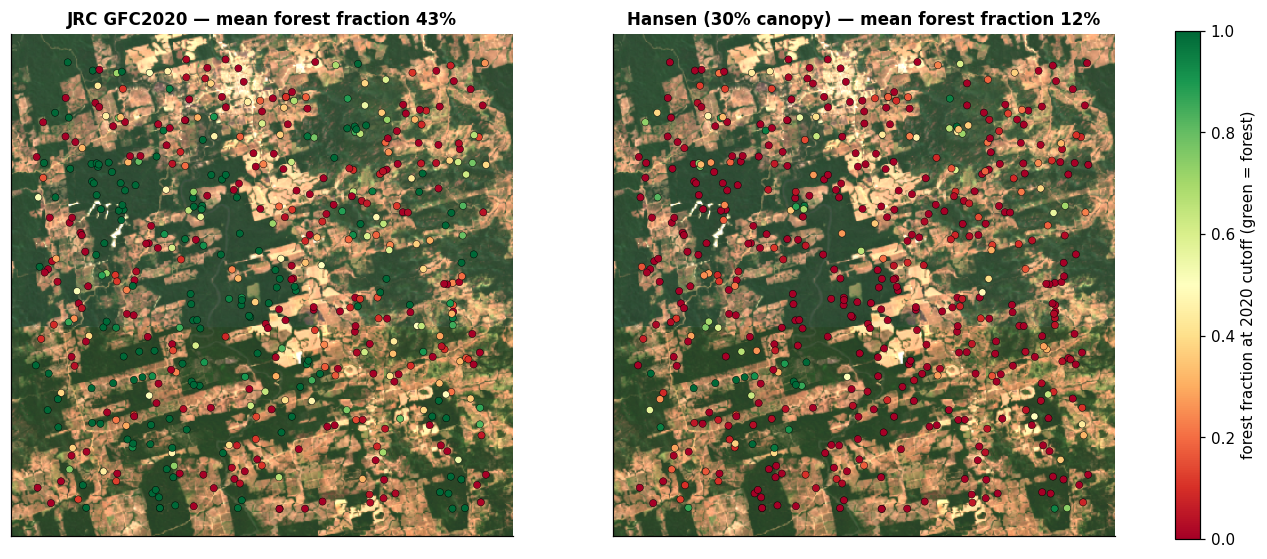

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
cmap = plt.get_cmap("RdYlGn")
norm = Normalize(0, 1)

for ax, col, name in ((axes[0], "forest_frac_jrc", "JRC GFC2020"),
                      (axes[1], "forest_frac_hansen", "Hansen (30% canopy)")):
    if aoi_rgb is not None:
        ax.imshow(aoi_rgb, extent=[cfg.AOI_BBOX[0], cfg.AOI_BBOX[2], cfg.AOI_BBOX[1], cfg.AOI_BBOX[3]],
                  origin="upper", alpha=0.85)
    ax.scatter(cx_all, cy_all, c=cmap(norm(gb[col])), s=22, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{name} — mean forest fraction {gb[col].mean():.0%}")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.025,
             label="forest fraction at 2020 cutoff (green = forest)")
viz.save(fig, "g02_fraction_maps")
plt.show()

### What a disagreement actually looks like

Abstract percentages are easy to wave away, so here are concrete cases: plots
where the two maps disagree most, each on its own Sentinel-2 chip. Look at what
they show — almost all are **JRC 100% / Hansen 0% over visibly green forest**.
That is the regrowth signature from above made visible: land that reads as
forest today (and to JRC's 2020 classification) but was either cleared or below
30% canopy in Hansen's year-2000 baseline, so Hansen's loss-accounting never
counts it back as forest. This is the land where a compliance verdict is
hardest, and where GeoVerdict refuses to hide the conflict.

figure saved: /content/drive/MyDrive/geoverdict/figures/g02_disagreement_gallery.png


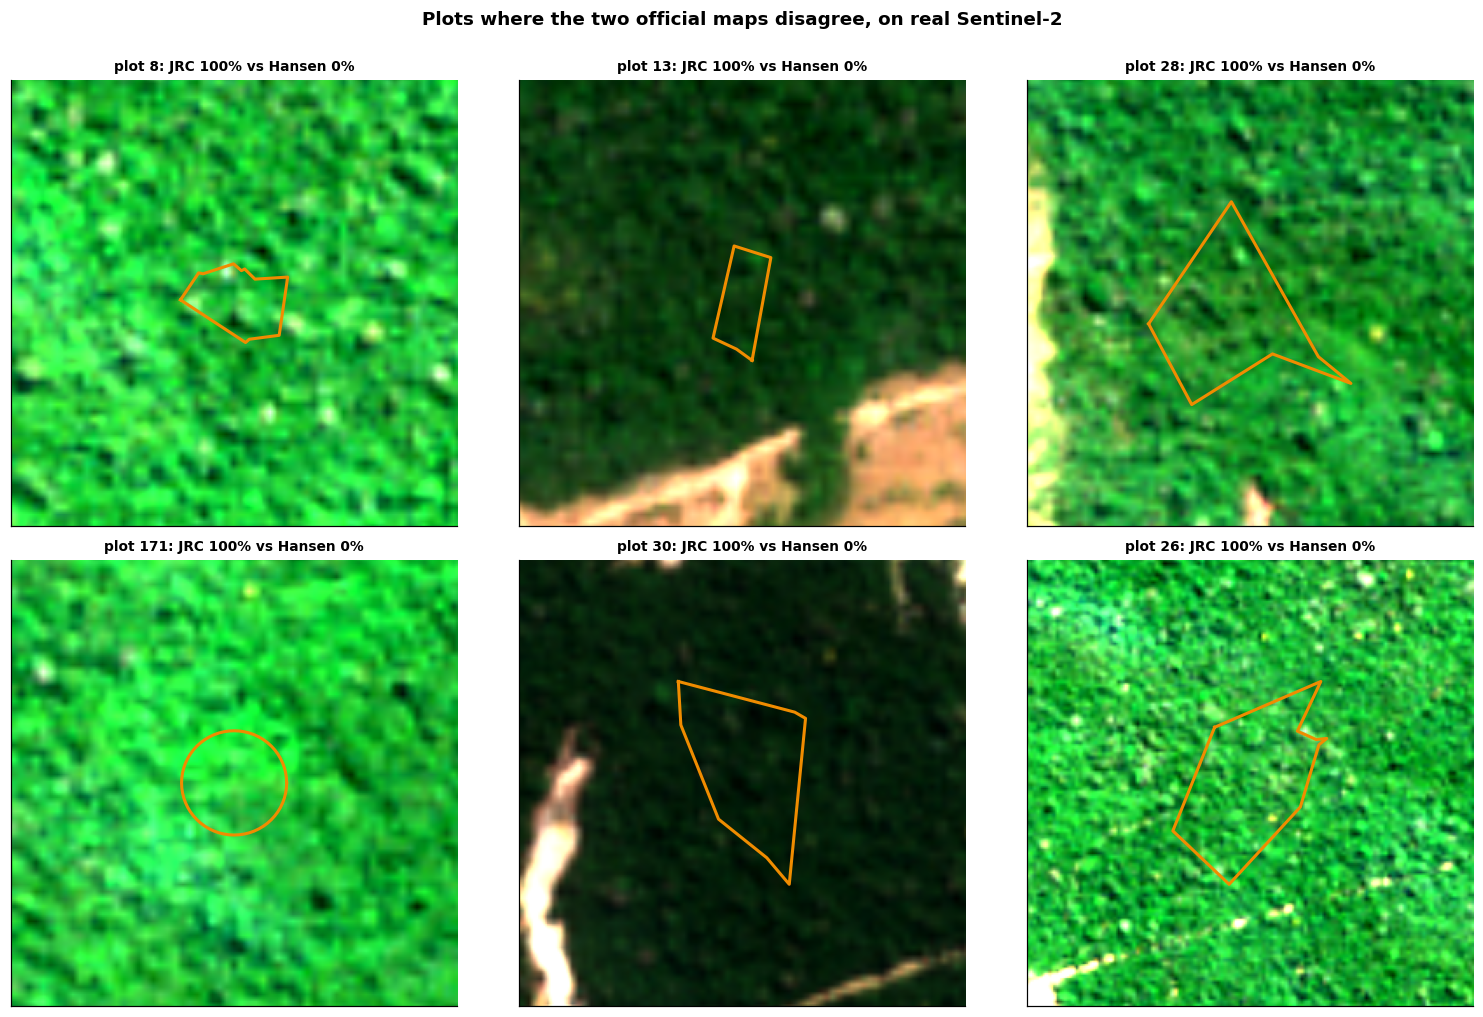

In [36]:
disagreers = gb[gb.maps_disagree].copy()
disagreers["gap"] = (disagreers.forest_frac_jrc - disagreers.forest_frac_hansen).abs()
show = disagreers.sort_values("gap", ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9.2))
for ax, (_, row) in zip(axes.ravel(), show.iterrows()):
    g = row.geometry
    rgb, bbox, *_ = s2.basemap_rgb(s2.geom_view_bbox(g, margin_frac=0.6), max_cloud=25, max_px=256)
    viz.plot_on_basemap(ax, rgb, bbox, [(g, dict(edgecolor=viz.PALETTE["warn"], lw=2.0))],
        title=f"plot {row.plot_id}: JRC {row.forest_frac_jrc:.0%} vs Hansen {row.forest_frac_hansen:.0%}")
fig.suptitle("Plots where the two official maps disagree, on real Sentinel-2",
             fontweight="bold", y=1.0)
fig.tight_layout()
viz.save(fig, "g02_disagreement_gallery")
plt.show()

### Why this matters (and what a production system does about it)

**Nearly 40% of plots** get a different compliance-relevant baseline depending on
which official map is consulted — and the disagreement is systematic (JRC counts
post-2000 regrowth as forest, Hansen does not), not random. For those plots the
verdict is a property of the *map choice*, not of the land — and a system that
silently picks one map is hiding a judgement call inside a lookup. GeoVerdict's
response, implemented in chapter 05: baseline disagreement is *itself a signal*
that caps the verdict at **MEDIUM** and states the conflict in the evidence
bundle, so a human sees exactly which authority said what and why.

Two honest caveats on the number:
- Our plots are *randomly placed* over a deforestation frontier; real farm
  portfolios cluster on roads and rivers — the fragmented edges where maps
  disagree most — so this is more likely a **floor** than a ceiling.
- The disagreement is a property of *this biome and frontier*; a different
  region (dense intact forest, or open cropland) would show far less. That
  regional dependence is itself the kind of thing this pipeline is built to
  measure rather than assume.

**Next:** chapter 03 stops asking maps and starts asking the satellite — six
years of Sentinel-2 over every plot, and a detector that finds the month the
forest signal broke.